# Project Completion Date Forecasting


In [1]:
import os
import glob
import json
import math
import random
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

!pip install -q xgboost catboost
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


## 1. Load the datasets

In [2]:
from google.colab import files

print("Upload BOTH files: 'Agile_Projects_Dataset.xlsx' and 'Jira task dataset.xlsx'")
uploaded = files.upload()

def find_uploaded(name_contains):
    matches = [f for f in uploaded if name_contains.lower() in f.lower()]
    if not matches:
        raise FileNotFoundError(f"No uploaded file matching '{name_contains}'. Uploaded: {list(uploaded.keys())}")
    return matches[0]

agile_path = find_uploaded("agile")
jira_path = find_uploaded("jira")
print("Agile file:", agile_path)
print("Jira file:", jira_path)


Upload BOTH files: 'Agile_Projects_Dataset.xlsx' and 'Jira task dataset.xlsx'


Saving Agile_Projects_Dataset.xlsx to Agile_Projects_Dataset.xlsx
Saving Jira task dataset.xlsx to Jira task dataset.xlsx
Agile file: Agile_Projects_Dataset.xlsx
Jira file: Jira task dataset.xlsx


In [3]:
df_agile_meta = pd.read_excel(agile_path)
df_agile_meta.columns = [c.strip() for c in df_agile_meta.columns]
df_agile_meta.head()


,Agile Effectiveness,Risk Mitigation,Management Satisfaction,Supply Chain Improvement,Time Efficiency,Cost Savings (%),Project Success
0,4,4,5,2,2,26,1
1,5,5,5,5,3,18,0
2,2,4,4,5,2,42,1
3,4,2,2,3,2,29,1
4,4,5,5,4,3,22,1


In [4]:
df_jira = pd.read_excel(jira_path)
df_jira.columns = [c.strip() for c in df_jira.columns]
df_jira.head()


,Summary,Status,Priority,Created,Resolved,Labels,Description
0,HR > Leaves > Half leave report filter added,Done,Medium,2024-11-19 16:19:00,2024-11-25 14:21:00,"HR,KICKER",HR > Leaves > Half leave report filter added
1,HR > Dashboard > terminate widgets set,Done,Medium,2024-11-19 16:07:00,2024-11-25 14:21:00,"HR,KICKER",HR > Dashboard > terminate widgets set
2,HR > Attendance > Fetch on Dynamic date,Done,Medium,2024-11-19 16:06:00,2024-11-25 14:21:00,"HR,Date",HR > Attendance > Fetch on Dynamic date
3,Store > Ledger > Separate Reserve flow of Kicker,Done,Medium,2024-11-19 16:00:00,2024-11-25 14:21:00,"KICKER,STORE",Store > Ledger > Separate Reserve flow of Kicker
4,HR > Extra > Separate Previous Balance Alert,Done,Medium,2024-11-19 15:58:00,2024-11-25 14:21:00,HR,HR > Extra > Separate Previous Balance Alert


## 2. Real data → calibration statistics

In [5]:
df_jira["Created"] = pd.to_datetime(df_jira["Created"])
df_jira["Resolved"] = pd.to_datetime(df_jira["Resolved"])
df_jira["duration_days"] = (df_jira["Resolved"] - df_jira["Created"]).dt.total_seconds() / 86400

df_jira = df_jira[(df_jira["duration_days"] > 0) & (df_jira["duration_days"] < 180)].copy()
df_jira["Priority"] = df_jira["Priority"].astype(str).str.strip().str.title()

priority_duration_stats = (
    df_jira.groupby("Priority")["duration_days"]
    .agg(["mean", "std", "count"])
    .to_dict(orient="index")
)
DEFAULT_PRIORITY_STATS = {
    "Low": {"mean": 5.0, "std": 3.0},
    "Medium": {"mean": 4.0, "std": 2.5},
    "High": {"mean": 3.0, "std": 2.0},
    "Critical": {"mean": 2.0, "std": 1.5},
}
for p, stats in DEFAULT_PRIORITY_STATS.items():
    if p not in priority_duration_stats or priority_duration_stats[p]["count"] < 5:
        priority_duration_stats[p] = {"mean": stats["mean"], "std": stats["std"], "count": 0}

print(priority_duration_stats)

weekly_counts = (
    df_jira.set_index("Resolved")
    .resample("W")
    .size()
)
weekly_counts = weekly_counts[weekly_counts > 0]
VELOCITY_MEAN = weekly_counts.mean()
VELOCITY_STD = weekly_counts.std()
print("Weekly throughput mean/std:", VELOCITY_MEAN, VELOCITY_STD)


{'Blocker': {'mean': 2.84375, 'std': nan, 'count': 1}, 'Critical': {'mean': 17.103911111111113, 'std': 18.925083113627956, 'count': 125}, 'High': {'mean': 19.470502136752135, 'std': 19.192016134728163, 'count': 65}, 'Low': {'mean': 40.35400563607086, 'std': 45.70892787181277, 'count': 138}, 'Lowest': {'mean': 0.00625, 'std': nan, 'count': 1}, 'Medium': {'mean': 17.06537126068376, 'std': 30.889936196273, 'count': 52}}
Weekly throughput mean/std: 5.380281690140845 9.67820260346945


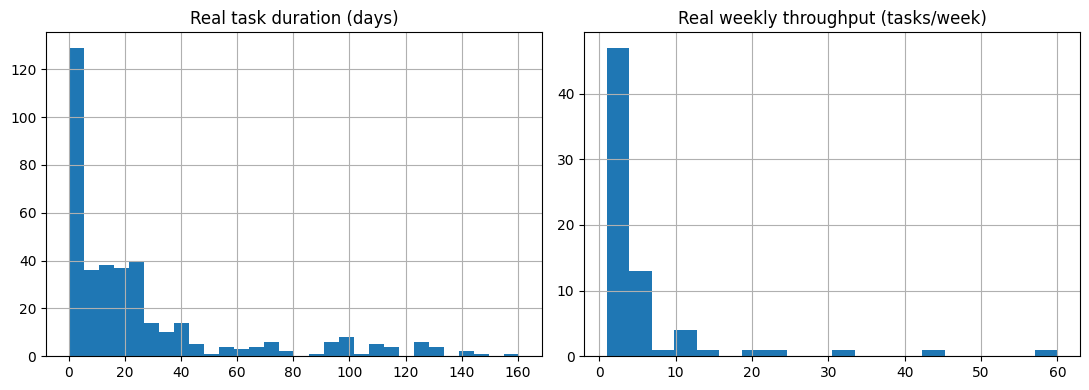

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df_jira["duration_days"].hist(bins=30, ax=axes[0])
axes[0].set_title("Real task duration (days)")
weekly_counts.hist(bins=20, ax=axes[1])
axes[1].set_title("Real weekly throughput (tasks/week)")
plt.tight_layout()
plt.show()


### 2.2 Kaggle dataset: a real efficiency_index

In [7]:
likert_cols = ["Agile Effectiveness", "Risk Mitigation", "Management Satisfaction",
               "Supply Chain Improvement", "Time Efficiency"]

df_agile_meta["likert_norm"] = df_agile_meta[likert_cols].apply(
    lambda row: (row - 2) / 3.0, axis=1  # Likert range is 2..5 -> normalize to 0..1
).mean(axis=1)

df_agile_meta["cost_savings_norm"] = (
    (df_agile_meta["Cost Savings (%)"] - df_agile_meta["Cost Savings (%)"].min())
    / (df_agile_meta["Cost Savings (%)"].max() - df_agile_meta["Cost Savings (%)"].min())
)

df_agile_meta["efficiency_index"] = (
    0.6 * df_agile_meta["likert_norm"] + 0.4 * df_agile_meta["cost_savings_norm"]
).clip(0.05, 0.98)

EFFICIENCY_DISTRIBUTION = df_agile_meta["efficiency_index"].values
print(df_agile_meta[["efficiency_index", "Project Success"]].describe())


       efficiency_index  Project Success
count        200.000000       200.000000
mean           0.504432         0.490000
std            0.164693         0.501154
min            0.090526         0.000000
25%            0.386842         0.000000
50%            0.508421         0.000000
75%            0.611579         1.000000
max            0.907368         1.000000


## 3. Synthetic project generator (calibrated on real data)


In [8]:
PRIORITY_MIX = {"Low": 0.30, "Medium": 0.40, "High": 0.22, "Critical": 0.08}

def sample_task_durations(n_tasks, dev_speed_factor):
    priorities = np.random.choice(
        list(PRIORITY_MIX.keys()), size=n_tasks, p=list(PRIORITY_MIX.values())
    )
    durations = np.empty(n_tasks)
    for i, p in enumerate(priorities):
        stats = priority_duration_stats[p]
        mu, sigma = stats["mean"], max(stats["std"], 0.5)
        d = np.random.normal(mu, sigma) * dev_speed_factor
        durations[i] = max(d, 0.25)
    return priorities, durations


def simulate_project(efficiency_index=None, rng=None):
    rng = rng or np.random
    if efficiency_index is None:
        efficiency_index = float(np.random.choice(EFFICIENCY_DISTRIBUTION))

    num_developers = int(np.clip(rng.normal(6, 3), 2, 15))
    original_total_tasks = int(np.clip(rng.normal(20 * num_developers, 8 * num_developers), 15, 600))

    dev_speed_factor = np.clip(1.4 - efficiency_index, 0.6, 1.3)
    priorities, durations = sample_task_durations(original_total_tasks, dev_speed_factor)
    order = np.argsort(durations) if rng.random() < 0.5 else np.random.permutation(original_total_tasks)
    queue_priority = list(priorities[order])
    queue_duration = list(durations[order])

    base_rate_per_dev = (VELOCITY_MEAN / 7.0) / 6.0
    base_team_capacity_per_day = base_rate_per_dev * math.sqrt(num_developers) * (0.6 + 0.6 * efficiency_index)
    base_team_capacity_per_day = max(base_team_capacity_per_day, 0.3)

    rough_est_duration = original_total_tasks / base_team_capacity_per_day

    has_scope_creep = np.random.random() < 0.35
    creep_day, creep_task_count = None, 0
    if has_scope_creep:
        creep_day = int(np.random.uniform(0.2, 0.7) * rough_est_duration)
        creep_fraction = np.random.uniform(0.05, 0.30)
        creep_task_count = max(1, int(original_total_tasks * creep_fraction))

    regime_multiplier = np.random.lognormal(mean=0.0, sigma=0.30)
    regime_days_left = np.random.randint(10, 35)

    day = 0
    completion_day = []
    task_priority_all = list(queue_priority)
    task_duration_all = list(queue_duration)
    idx_ptr = 0
    creep_applied = False

    max_days = 5 * 365
    while idx_ptr < len(task_priority_all) and day < max_days:
        day += 1

        regime_days_left -= 1
        if regime_days_left <= 0:
            regime_multiplier = np.random.lognormal(mean=0.0, sigma=0.30)
            regime_days_left = np.random.randint(10, 35)

        if has_scope_creep and not creep_applied and day >= creep_day:
            new_priorities, new_durations = sample_task_durations(creep_task_count, dev_speed_factor)
            task_priority_all.extend(new_priorities)
            task_duration_all.extend(new_durations)
            creep_applied = True

        daily_noise = np.random.normal(1.0, 0.25)
        if np.random.random() < 0.05:
            daily_noise *= 0.2
        today_capacity = max(base_team_capacity_per_day * regime_multiplier * daily_noise, 0.0)

        work_done_today = 0.0
        while idx_ptr < len(task_priority_all) and work_done_today < today_capacity:
            work_done_today += 1
            completion_day.append(day)
            idx_ptr += 1

    actual_total_duration_days = day
    total_tasks_final = len(task_priority_all)
    if len(completion_day) < total_tasks_final:
        completion_day.extend([day] * (total_tasks_final - len(completion_day)))
    completion_day = np.array(completion_day)

    return {
        "num_developers": num_developers,
        "original_total_tasks": original_total_tasks,
        "total_tasks_final": total_tasks_final,
        "efficiency_index": efficiency_index,
        "task_priority": np.array(task_priority_all),
        "task_duration": np.array(task_duration_all),
        "completion_day": completion_day,
        "actual_total_duration_days": actual_total_duration_days,
        "has_scope_creep": has_scope_creep,
        "creep_day": creep_day,
    }


In [9]:
def build_snapshot_row(sim, snapshot_frac=None, deadline_bias=None):
    completion_day = sim["completion_day"]
    actual_total_duration_days = sim["actual_total_duration_days"]
    task_priority = sim["task_priority"]
    task_duration = sim["task_duration"]
    original_total_tasks = sim["original_total_tasks"]
    has_scope_creep = sim["has_scope_creep"]
    creep_day = sim["creep_day"]

    if snapshot_frac is None:
        snapshot_frac = np.random.uniform(0.10, 0.85)
    t = max(1, int(actual_total_duration_days * snapshot_frac))

    if has_scope_creep and creep_day is not None and t >= creep_day:
        total_tasks_known = sim["total_tasks_final"]
    else:
        total_tasks_known = original_total_tasks

    known_mask = np.arange(len(task_priority)) < total_tasks_known
    closed_mask = (completion_day <= t) & known_mask
    closed_tasks = int(closed_mask.sum())
    if closed_tasks == 0:
        candidate_days = np.where(known_mask, completion_day, np.inf)
        closed_mask = np.zeros_like(closed_mask)
        closed_mask[int(np.argmin(candidate_days))] = True
        closed_tasks = 1

    open_mask = known_mask & (~closed_mask)
    num_critical_tasks_open = int(((task_priority == "Critical") | (task_priority == "High"))[open_mask].sum())

    avg_task_duration_days = float(task_duration[closed_mask].mean())

    recent_window = (completion_day > max(0, t - 7)) & (completion_day <= t) & known_mask
    velocity = float(recent_window.sum())

    if deadline_bias is None:
        deadline_bias = np.random.normal(1.0, 0.15)
    deadline_days_total = actual_total_duration_days * max(deadline_bias, 0.5)
    deadline_days_remaining = deadline_days_total - t

    remaining_days = actual_total_duration_days - t

    return {
        "total_tasks": total_tasks_known,
        "closed_tasks": closed_tasks,
        "velocity": velocity,
        "num_developers": sim["num_developers"],
        "avg_task_duration_days": avg_task_duration_days,
        "num_critical_tasks_open": num_critical_tasks_open,
        "deadline_days_remaining": deadline_days_remaining,
        "efficiency_index": sim["efficiency_index"],
        "remaining_days": remaining_days,
    }


### 3.1 Generate the pure-synthetic pool


In [10]:
N_PURE_SYNTHETIC = 4000

synthetic_rows = []
for _ in range(N_PURE_SYNTHETIC):
    sim = simulate_project()
    row = build_snapshot_row(sim)
    synthetic_rows.append(row)

df_synth = pd.DataFrame(synthetic_rows)
df_synth["source"] = "pure_synthetic"
df_synth.describe()


,total_tasks,closed_tasks,velocity,num_developers,avg_task_duration_days,num_critical_tasks_open,deadline_days_remaining,efficiency_index,remaining_days
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,111.510750,53.225250,6.894500,5.625500,15.969220,16.570250,59.082388,0.504610,59.365000
std,73.490595,45.763901,0.611116,2.700754,11.725733,15.619109,52.901422,0.164390,49.433584
min,15.000000,1.000000,1.000000,2.000000,0.250000,0.000000,-49.972605,0.090526,3.000000
25%,54.000000,20.000000,7.000000,3.000000,5.076665,5.000000,21.680282,0.385263,24.000000
50%,95.000000,40.000000,7.000000,5.000000,15.825937,12.000000,44.013124,0.507368,44.000000
75%,153.000000,74.000000,7.000000,7.000000,25.121956,23.000000,80.767068,0.608421,79.000000
max,493.000000,357.000000,10.000000,15.000000,63.383581,117.000000,395.673972,0.907368,360.000000


### 3.2 Generate semi-synthetic rows grounded in the real Kaggle dataset


In [11]:
semi_rows = []
for _, r in df_agile_meta.iterrows():
    eff = float(r["efficiency_index"])
    success = int(r["Project Success"])
    bias_center = 1.05 if success == 1 else 0.85
    deadline_bias = np.random.normal(bias_center, 0.12)

    sim = simulate_project(efficiency_index=eff)
    row = build_snapshot_row(sim, deadline_bias=deadline_bias)
    row["source"] = "semi_synthetic_from_kaggle"
    semi_rows.append(row)

df_semi = pd.DataFrame(semi_rows)
df_semi.describe()


,total_tasks,closed_tasks,velocity,num_developers,avg_task_duration_days,num_critical_tasks_open,deadline_days_remaining,efficiency_index,remaining_days
count,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,113.690000,54.650000,6.89500,5.715000,15.367002,16.805000,54.728334,0.504432,60.855000
std,69.707457,42.356557,0.53423,2.570371,11.554747,15.583362,50.935710,0.164693,48.830483
min,15.000000,3.000000,3.00000,2.000000,0.250000,0.000000,-18.649941,0.090526,5.000000
25%,57.000000,25.000000,7.00000,4.000000,5.504816,5.000000,17.261587,0.386842,24.000000
50%,96.500000,43.500000,7.00000,6.000000,13.809235,12.000000,40.687236,0.508421,44.500000
75%,155.250000,73.250000,7.00000,7.000000,24.602434,24.000000,72.334809,0.611579,87.250000
max,363.000000,248.000000,8.00000,13.000000,53.219082,86.000000,247.232797,0.907368,236.000000


In [12]:
training_df = pd.concat([df_synth, df_semi], ignore_index=True)
training_df = training_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
print(training_df.shape)
training_df.head()


(4200, 10)


,total_tasks,closed_tasks,velocity,num_developers,avg_task_duration_days,num_critical_tasks_open,deadline_days_remaining,efficiency_index,remaining_days,source
0,165,108,7.0,7,8.041038,9,42.301227,0.703158,57,pure_synthetic
1,358,95,7.0,10,27.301882,78,278.742383,0.458947,263,pure_synthetic
2,106,13,7.0,5,0.250000,26,73.110489,0.433684,93,pure_synthetic
3,26,9,7.0,2,16.784325,5,15.623665,0.658947,17,pure_synthetic
4,68,56,7.0,4,14.773368,0,14.040507,0.658947,12,pure_synthetic


## 4. Historical "similar projects" feature (leakage-safe)


In [13]:
def fit_similarity_lookup(train_df, k=10):
    feats = train_df[["total_tasks", "num_developers"]].values.astype(float)
    mu, sigma = feats.mean(axis=0), feats.std(axis=0) + 1e-6
    feats_scaled = (feats - mu) / sigma
    nn = NearestNeighbors(n_neighbors=k + 1).fit(feats_scaled)
    return {"nn": nn, "mu": mu, "sigma": sigma, "targets": train_df["remaining_days"].values, "k": k}


def apply_similarity_lookup(lookup, query_df, exclude_self=False):
    feats = query_df[["total_tasks", "num_developers"]].values.astype(float)
    feats_scaled = (feats - lookup["mu"]) / lookup["sigma"]
    n_neighbors = lookup["k"] + 1 if exclude_self else lookup["k"]
    dist, idx = lookup["nn"].kneighbors(feats_scaled, n_neighbors=n_neighbors)
    if exclude_self:
        idx = idx[:, 1:]
    return lookup["targets"][idx].mean(axis=1)


## 5. Train / test split


In [14]:
FEATURE_COLS = [
    "total_tasks", "closed_tasks", "velocity", "num_developers",
    "avg_task_duration_days", "num_critical_tasks_open",
    "deadline_days_remaining", "efficiency_index",
]
TARGET_COL = "remaining_days"

train_df, test_df = train_test_split(training_df, test_size=0.2, random_state=SEED)

similarity_lookup = fit_similarity_lookup(train_df, k=10)
train_df = train_df.copy()
test_df = test_df.copy()
train_df["historical_similar_avg_duration"] = apply_similarity_lookup(similarity_lookup, train_df, exclude_self=True)
test_df["historical_similar_avg_duration"] = apply_similarity_lookup(similarity_lookup, test_df, exclude_self=False)

FEATURE_COLS_FULL = FEATURE_COLS + ["historical_similar_avg_duration"]

X_train, y_train = train_df[FEATURE_COLS_FULL], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS_FULL], test_df[TARGET_COL]

print(X_train.shape, X_test.shape)


(3360, 9) (840, 9)


## 6. Model training & comparison


In [15]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    preds = np.clip(preds, 0, None)
    mae = mean_absolute_error(y_te, preds)
    rmse = math.sqrt(mean_squared_error(y_te, preds))
    mape = float(np.mean(np.abs((y_te - preds) / np.clip(y_te, 1, None))) * 100)
    r2 = r2_score(y_te, preds)
    print(f"{name:22s} MAE={mae:6.2f}  RMSE={rmse:6.2f}  MAPE={mape:6.2f}%  R2={r2:5.3f}")
    return {"name": name, "model": model, "mae": mae, "rmse": rmse, "mape": mape, "r2": r2, "preds": preds}


results = []
results.append(evaluate("LinearRegression",
                         LinearRegression(),
                         X_train, y_train, X_test, y_test))

results.append(evaluate("RandomForest",
                         RandomForestRegressor(n_estimators=300, max_depth=12, random_state=SEED),
                         X_train, y_train, X_test, y_test))

results.append(evaluate("XGBoost",
                         XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                      subsample=0.8, colsample_bytree=0.8, random_state=SEED),
                         X_train, y_train, X_test, y_test))

results.append(evaluate("CatBoost",
                         CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05,
                                           random_seed=SEED, verbose=False),
                         X_train, y_train, X_test, y_test))


LinearRegression       MAE=  2.48  RMSE=  6.74  MAPE=  4.15%  R2=0.981
RandomForest           MAE=  6.02  RMSE=  9.30  MAPE= 13.19%  R2=0.964
XGBoost                MAE=  4.48  RMSE=  7.74  MAPE=  9.39%  R2=0.975
CatBoost               MAE=  5.08  RMSE=  8.27  MAPE= 11.50%  R2=0.972


In [16]:
best = min(results, key=lambda r: r["mape"])
print("\nBest model:", best["name"], f"(MAPE={best['mape']:.2f}%, R2={best['r2']:.3f})")
best_model = best["model"]



Best model: LinearRegression (MAPE=4.15%, R2=0.981)


### 6.1 Feature importance (best model)


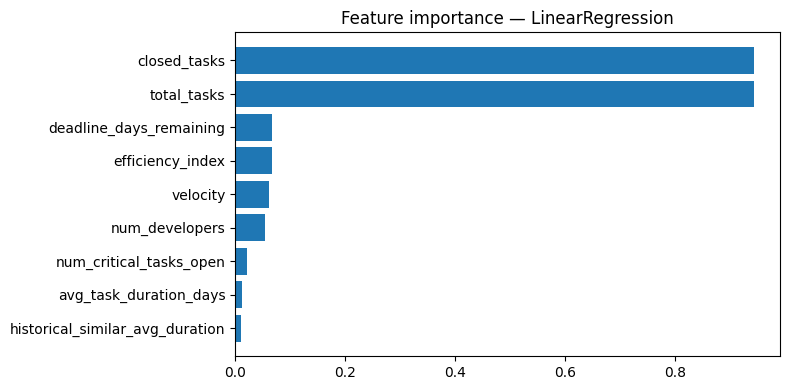

In [17]:
importances = None
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_)

if importances is not None:
    order = np.argsort(importances)[::-1]
    plt.figure(figsize=(8, 4))
    plt.barh(np.array(FEATURE_COLS_FULL)[order][::-1], importances[order][::-1])
    plt.title(f"Feature importance — {best['name']}")
    plt.tight_layout()
    plt.show()


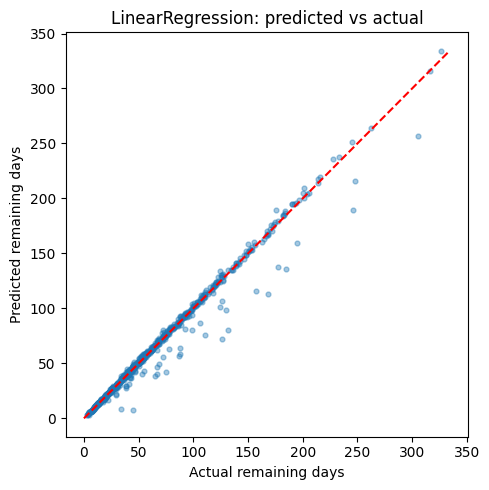

In [18]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, best["preds"], alpha=0.4, s=12)
lims = [0, max(y_test.max(), best["preds"].max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual remaining days")
plt.ylabel("Predicted remaining days")
plt.title(f"{best['name']}: predicted vs actual")
plt.tight_layout()
plt.show()


## 7. Turning a prediction into a completion date


In [19]:
from datetime import datetime

def predict_completion_date(model, project_state: dict, snapshot_date: datetime, lookup=None, model_mape=None):

    row = pd.DataFrame([project_state])
    if lookup is not None:
        row["historical_similar_avg_duration"] = apply_similarity_lookup(lookup, row, exclude_self=False)
    else:
        row["historical_similar_avg_duration"] = np.nan

    row = row[FEATURE_COLS_FULL]
    pred_remaining_days = max(float(model.predict(row)[0]), 0.0)
    predicted_date = snapshot_date + timedelta(days=pred_remaining_days)

    result = {
        "predicted_remaining_days": round(pred_remaining_days, 1),
        "predicted_completion_date": predicted_date.date().isoformat(),
    }
    if model_mape is not None:
        margin_days = pred_remaining_days * (model_mape / 100.0)
        result["estimated_range"] = [
            (snapshot_date + timedelta(days=max(pred_remaining_days - margin_days, 0))).date().isoformat(),
            (snapshot_date + timedelta(days=pred_remaining_days + margin_days)).date().isoformat(),
        ]
    return result


example_project = {
    "total_tasks": 120,
    "closed_tasks": 65,
    "velocity": 9,
    "num_developers": 6,
    "avg_task_duration_days": 3.2,
    "num_critical_tasks_open": 4,
    "deadline_days_remaining": 20,
    "efficiency_index": 0.62,
}

predict_completion_date(best_model, example_project, datetime.today(),
                         lookup=similarity_lookup, model_mape=best["mape"])


{'predicted_remaining_days': 54.0,
 'predicted_completion_date': '2026-09-19',
 'estimated_range': ['2026-09-17', '2026-09-22']}

## 8. Save the model artifact


In [20]:
import joblib

ARTIFACT_PATH = "completion_date_model.joblib"
joblib.dump({
    "model": best_model,
    "model_name": best["name"],
    "feature_cols": FEATURE_COLS_FULL,
    "similarity_lookup": similarity_lookup,
    "validation_mape": best["mape"],
    "validation_r2": best["r2"],
    "trained_at": datetime.today().isoformat(),
}, ARTIFACT_PATH)

files.download(ARTIFACT_PATH)
print("Saved:", ARTIFACT_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: completion_date_model.joblib
